# part 1

In [44]:
%load_ext autoreload
%autoreload 2

In [47]:
import os
import sys
import env
import src.utils.engine as engine

import numpy as np
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt

from src.p1_edge_identification import *

In [59]:
image = Image.open(env.p1.chessboard_path)
image = ContourImage(image)
binary_image = image.prepare()
foreground = 0

In [66]:
# use Sobel operator for edge detection
def convolve(image, kernel):
    rows, cols = image.shape
    output = np.zeros_like(image)

    k_size = kernel.shape[0] // 2
    for i in range(k_size, rows - k_size):
        for j in range(k_size, cols - k_size):
            window = image[i-k_size:i+k_size+1, j-k_size:j+k_size+1]
            output[i, j] = abs(np.sum(window * kernel))  # Sum weighted region

    return output

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
])
sobel_y = sobel_x.transpose()

binary_image_array = np.array(binary_image)

foreground_mask = (binary_image_array == foreground) * 255

edges_x = convolve(foreground_mask, sobel_x)
edges_y = convolve(foreground_mask, sobel_y)
edges = np.sqrt(edges_x**2 + edges_y**2)
edges = (edges / edges.max()) * 255 # normalize to pixel range

height, width = edges.shape
edge_coordinates = [(y, x) for x in range(width) for y in range(height)
                    if edges[y, x] > BINARIZE_THRESHOLD]


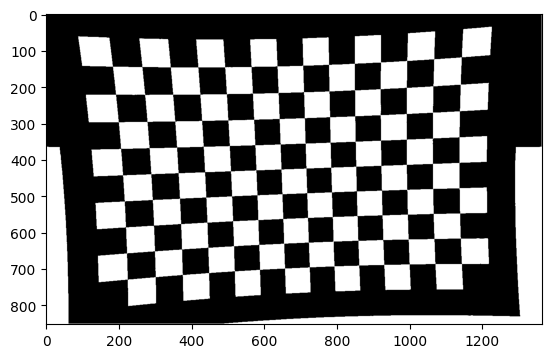

In [67]:
plt.imshow(foreground_mask, cmap="gray")

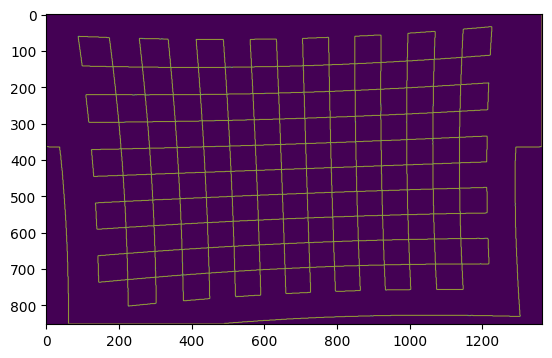

In [68]:
plt.imshow(edges)

In [22]:
max(edge_coordinates)

(1363, 851)